# TDA Parameter Recovery on Simulated Density Fields

Density fields are simulated from known $(\widehat R,\widehat D)$, and those parameters are re-estimated from the persistence diagrams of the resulting images. This notebook reads what the scripts wrote; it recomputes nothing. Set `MODEL` below.

## 1. Scaling

$$\frac{\partial\rho}{\partial t}=D\nabla^2\rho+R f(\rho),\qquad f(\rho)=\rho\ \text{(Model 1)}\quad\text{or}\quad\rho\left(1-\tfrac{\rho}{K}\right)\ \text{(Model 2)}$$

$$\hat\rho=\rho/K,\quad \hat x=x/L_0,\quad \hat t=t/T
\;\Longrightarrow\;
\frac{\partial\hat\rho}{\partial\hat t}=\widehat D\,\hat\nabla^2\hat\rho+\widehat R\,f(\hat\rho),\qquad \hat t\in[0,1]$$

| quantity | definition |
|---|---|
| $\widehat R$ | $RT$ |
| $\widehat D$ | $DT/L_0^2$ |
| $\tau,\ \alpha$ | $\widehat R,\ \widehat D/\widehat R=D/(RL_0^2)$ |
| $\sqrt{\alpha}$ | characteristic length $/\,L_0$ |
| $K$ | $1$ under Model 2 by the scaling; Model 1 has none |

`single_snapshot` reports $\widehat D/\widehat R$; `run_scenarios.py` converts a `multi_frame` result to $R$ and $D$ with units when `--elapsed-time` and `--domain-length` are given. Derivation: `tda_synth/scaling.py`.

## 2. Method

- Four sealed initial conditions, reported separately.
- Observation: Gaussian smoothing on the grid the PDE is solved on.
- Descriptor: periodic cubical persistence on $H_0$ and $H_1$ of the superlevel filtration $\rho_{\text{ref}}-\rho$, against one shared reference.
- Loss: 2-Wasserstein between diagrams, standardized by the median pairwise distance in the candidate library.
- Search: $15\times13$ coarse grid, then two-start bounded Nelder-Mead. The truths lie off that grid.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'

MODEL = 'model2'          # 'model1' (linear) or 'model2' (logistic)
tag = MODEL

summary = json.loads((RESULTS / f'recovery_summary_{tag}.json').read_text())
cases = pd.read_csv(RESULTS / f'recovery_cases_{tag}.csv')
surface = pd.read_csv(RESULTS / f'recovery_surface_{tag}.csv')
print('Model     :', summary['model'], '|', summary['equation'])
if summary.get('K') is None:
    print('Capacity  :', summary['carrying_capacity_definition'])
else:
    print('K fixed   :', summary['K'], '| recovered:', summary['K_is_recovered'])
print('One snapshot per recovery:', summary['one_snapshot_per_recovery'])
print('Units     :', summary['units']['all'])
print()
for key, value in summary.get('parameter_definition', {}).items():
    print(f'{key:>10}: {value}')

Model     : logistic | d(rho)/d(t_hat) = D_hat*lap_hat(rho) + R_hat*rho*(1-rho)
K fixed   : 1.0 | recovered: False
One snapshot per recovery: True
Units     : dimensionless

  equation: d(rho)/d(t_hat) = D_hat*lap_hat(rho) + R_hat*rho*(1-rho)
     R_hat: R * T
     D_hat: D * T / L0**2
       tau: R_hat, written as tau in the (tau, alpha) pair
     alpha: D_hat / R_hat, the ratio; equals D / (R * L0**2)
         T: the reference time; not measured from one snapshot
 reference: tda_synth/scaling.py


## 3. Initial conditions, target and recovered field

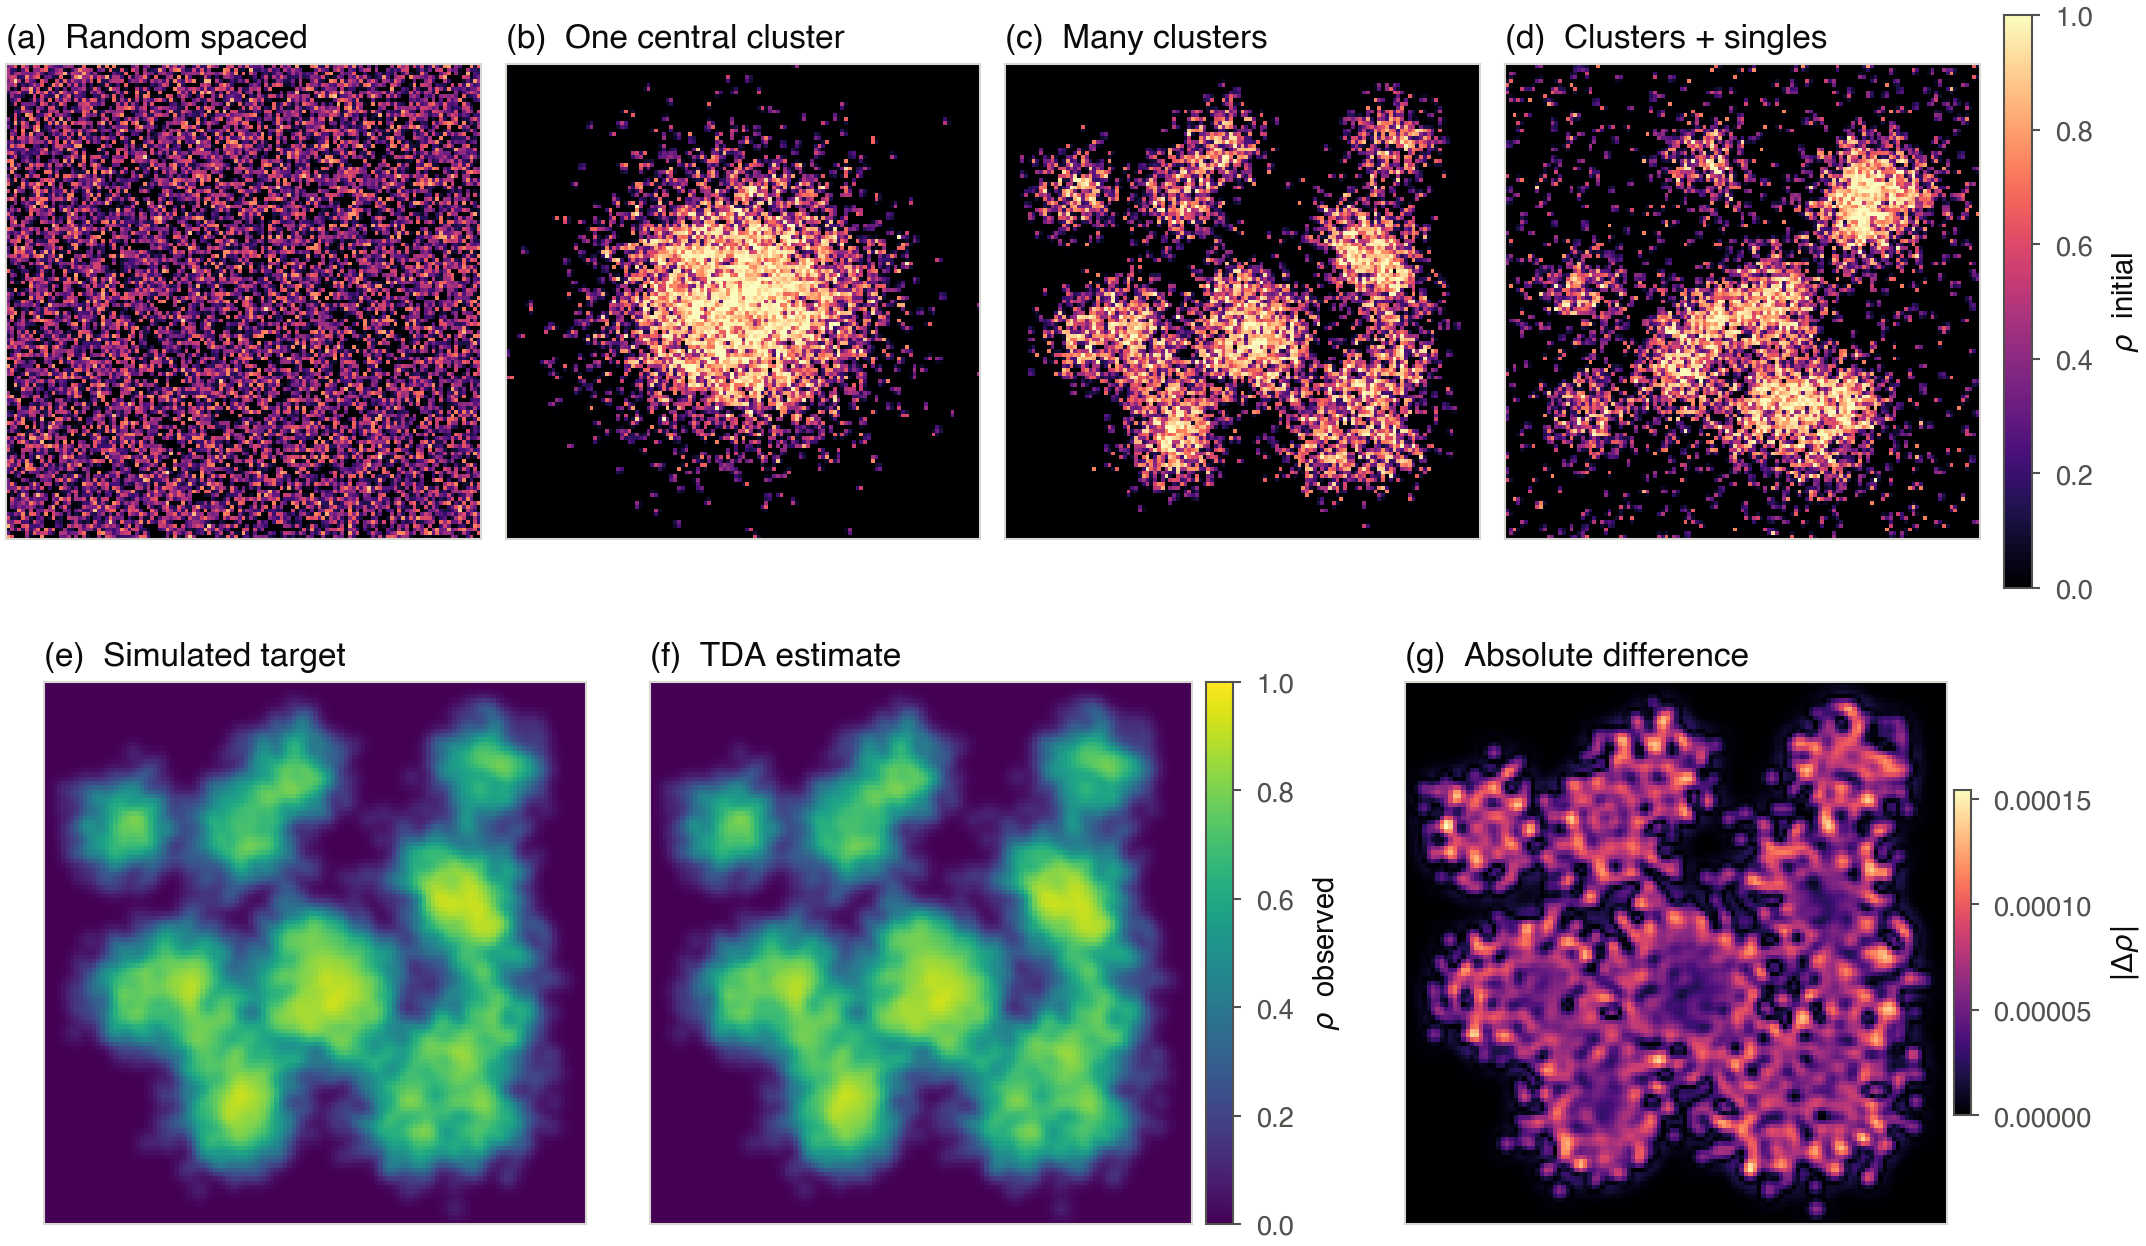

In [2]:
display(Image(filename=str(RESULTS / f'recovery_fields_{tag}.png')))

## 4. Off-grid recoveries

In [3]:
columns = [
    'case_id', 'ic_name', 'feature_set', 'dimensions_used',
    'true_rhat', 'estimated_rhat', 'rhat_relative_error',
    'true_dhat', 'estimated_dhat', 'dhat_relative_error',
    'true_alpha', 'estimated_alpha', 'alpha_relative_error',
    'estimated_length_scale_ratio',
]
columns = [c for c in columns if c in cases.columns]
display(cases[columns].round(7))

,case_id,ic_name,feature_set,dimensions_used,true_rhat,estimated_rhat,rhat_relative_error,true_dhat,estimated_dhat,dhat_relative_error,true_alpha,estimated_alpha,alpha_relative_error,estimated_length_scale_ratio
0,case_000,Random spaced,h0,h0,0.739,0.739074,0.000100,0.000096,0.000096,0.000050,0.000130,0.000130,0.000150,0.011382
1,case_000,Random spaced,h0h1,h0h1,0.739,0.738920,0.000108,0.000096,0.000096,0.000396,0.000130,0.000130,0.000287,0.011382
2,case_000,One central cluster,h0,h0,0.739,0.738997,0.000004,0.000096,0.000096,0.000296,0.000130,0.000130,0.000300,0.011385
3,case_000,One central cluster,h0h1,h0h1,0.739,0.739305,0.000413,0.000096,0.000096,0.000296,0.000130,0.000130,0.000116,0.011383
4,case_000,Many clusters,h0,h0,0.739,0.738843,0.000212,0.000096,0.000096,0.001103,0.000130,0.000130,0.001316,0.011391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,case_015,One central cluster,h0h1,h0h1,0.640,0.639590,0.000641,0.000120,0.000120,0.000543,0.000188,0.000188,0.001184,0.013716
124,case_015,Many clusters,h0,h0,0.640,0.639898,0.000159,0.000120,0.000120,0.000359,0.000188,0.000188,0.000518,0.013711
125,case_015,Many clusters,h0h1,h0h1,0.640,0.640206,0.000322,0.000120,0.000120,0.000284,0.000188,0.000188,0.000605,0.013703
126,case_015,Clusters + singles,h0,h0,0.640,0.640206,0.000322,0.000120,0.000120,0.000008,0.000188,0.000188,0.000330,0.013705


## 5. Settings the main sweep holds fixed

Target and candidates share the solver, the observation operator and the initial condition, and the fields are noise-free. Section 7 varies the operator, the noise and the smoothing width.

Text(0.5, 0.98, 'One-image recovery error, by initial condition')

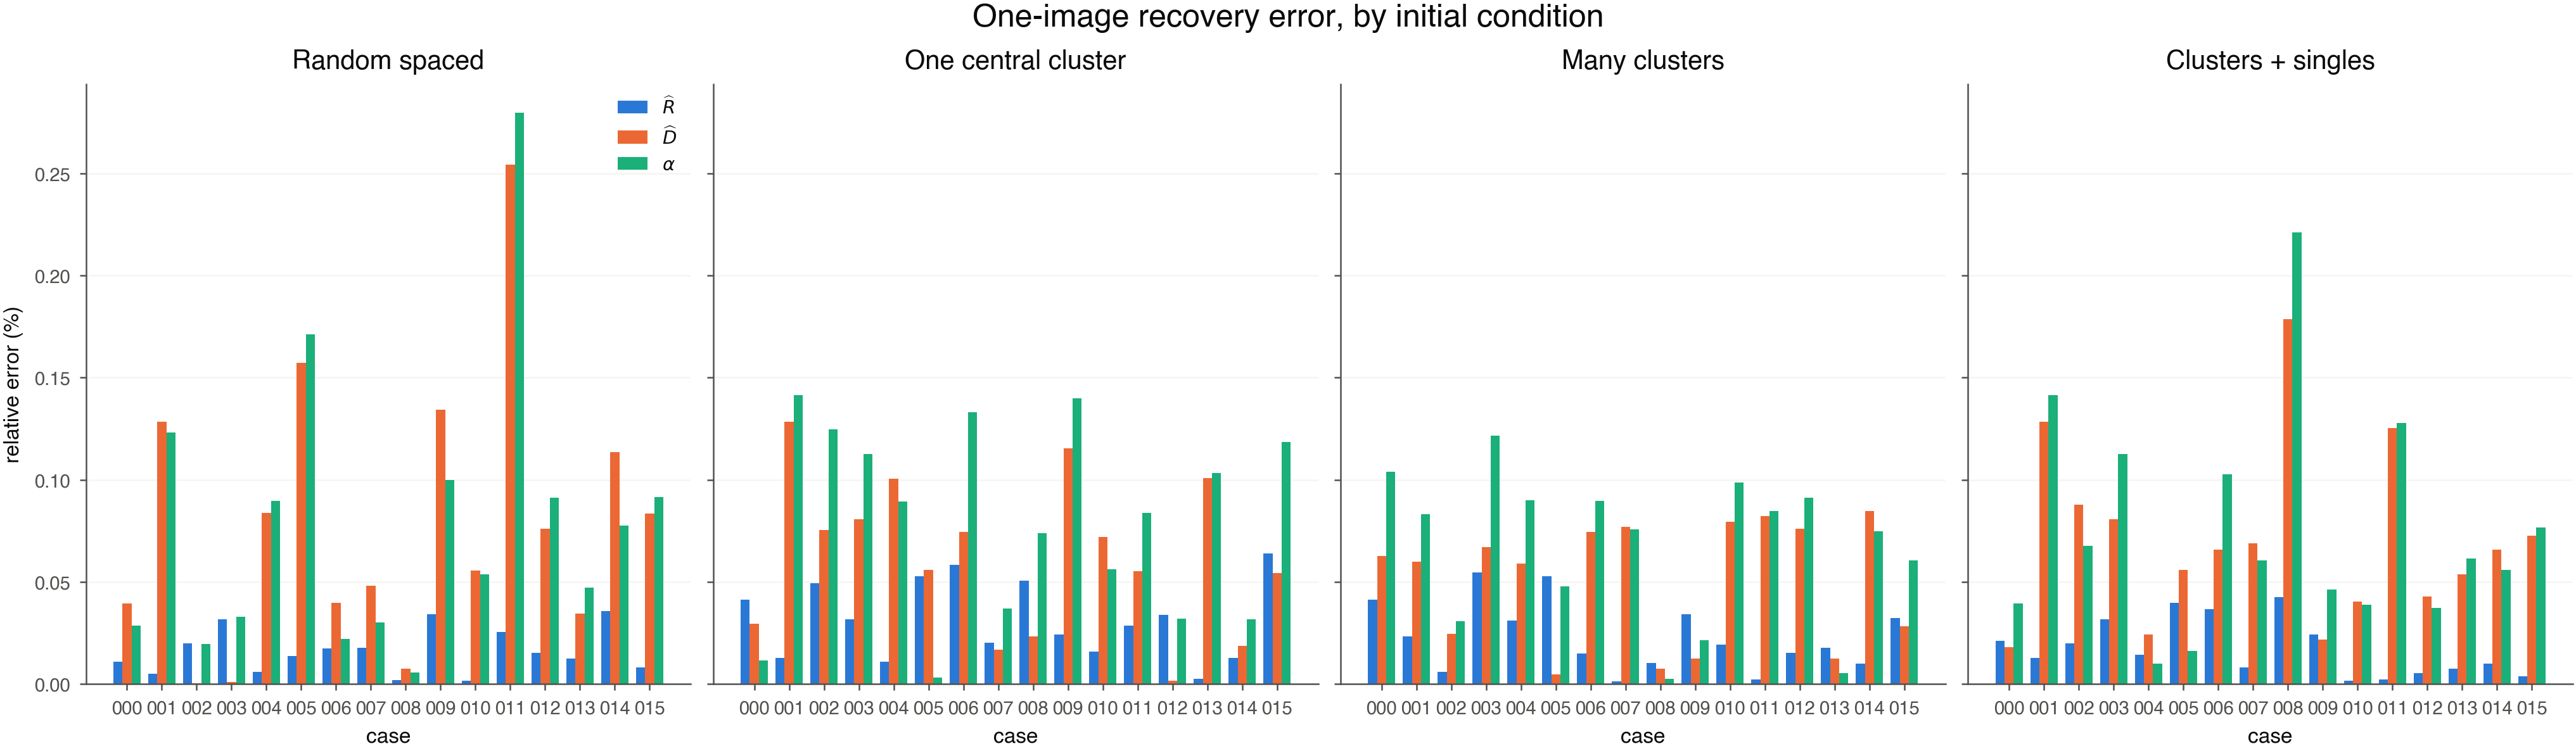

In [4]:
from tda_synth.plotting import PALETTE

primary = cases[cases.feature_set == 'h0h1'].copy()
ic_names = list(dict.fromkeys(primary.ic_name))
fig, axes = plt.subplots(1, len(ic_names), figsize=(3.4 * len(ic_names), 4.0),
                         sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)
series = [(r'$\widehat R$', 'rhat_relative_error'),
          (r'$\widehat D$', 'dhat_relative_error'),
          (r'$\alpha$', 'alpha_relative_error')]
width = 0.26
for ax, ic in zip(axes, ic_names):
    block = primary[primary.ic_name == ic]
    x = np.arange(len(block))
    for position, (label, column) in enumerate(series):
        offset = (position - 1) * width
        ax.bar(x + offset, 100 * block[column], width, color=PALETTE[position],
               label=label if ic == ic_names[0] else None)
    ax.set_title(ic, fontsize=10)
    ax.set_xticks(x, [c.replace('case_', '') for c in block.case_id], fontsize=7)
    ax.set_xlabel('case')
    ax.grid(axis='y', alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel('relative error (%)')
axes[0].legend(frameon=False)
fig.suptitle('One-image recovery error, by initial condition', fontsize=12)

## 6. Loss surface and target diagram

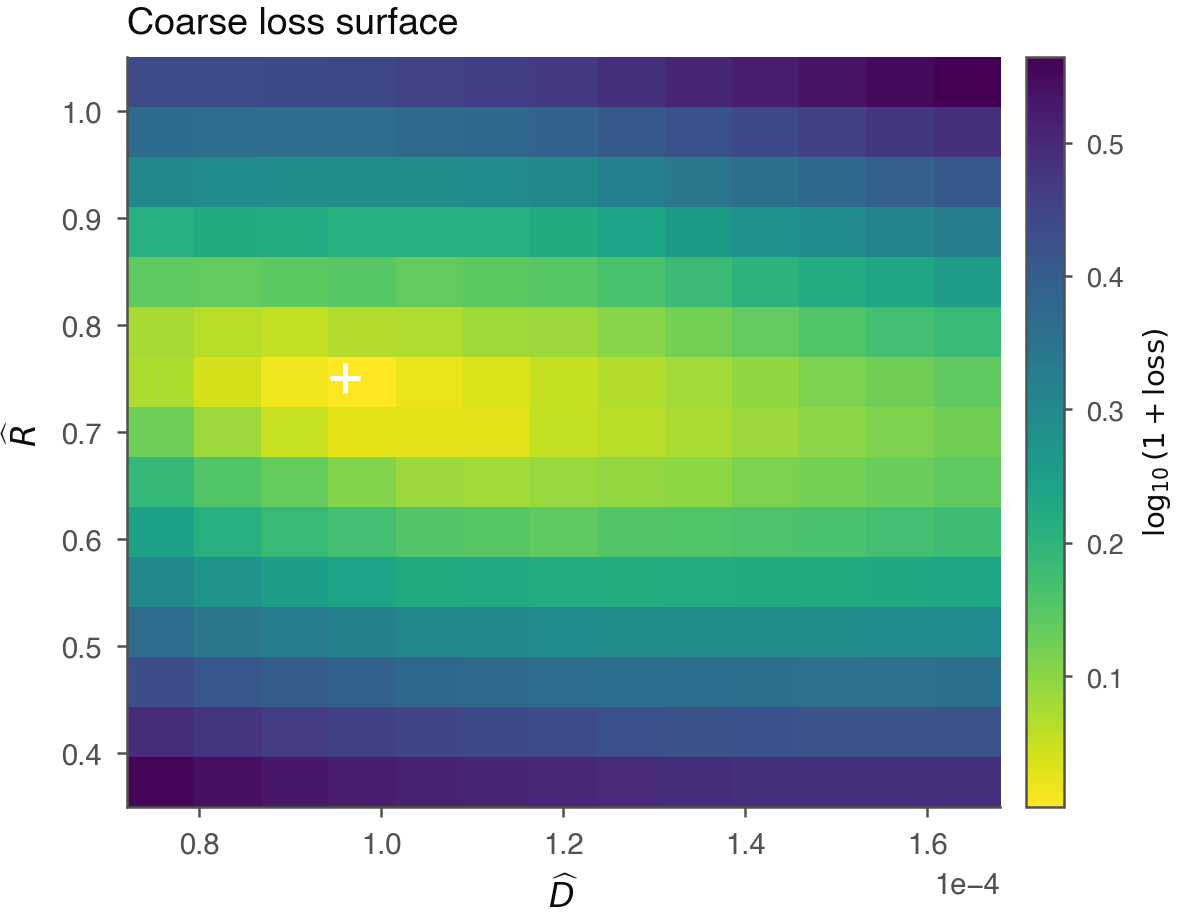

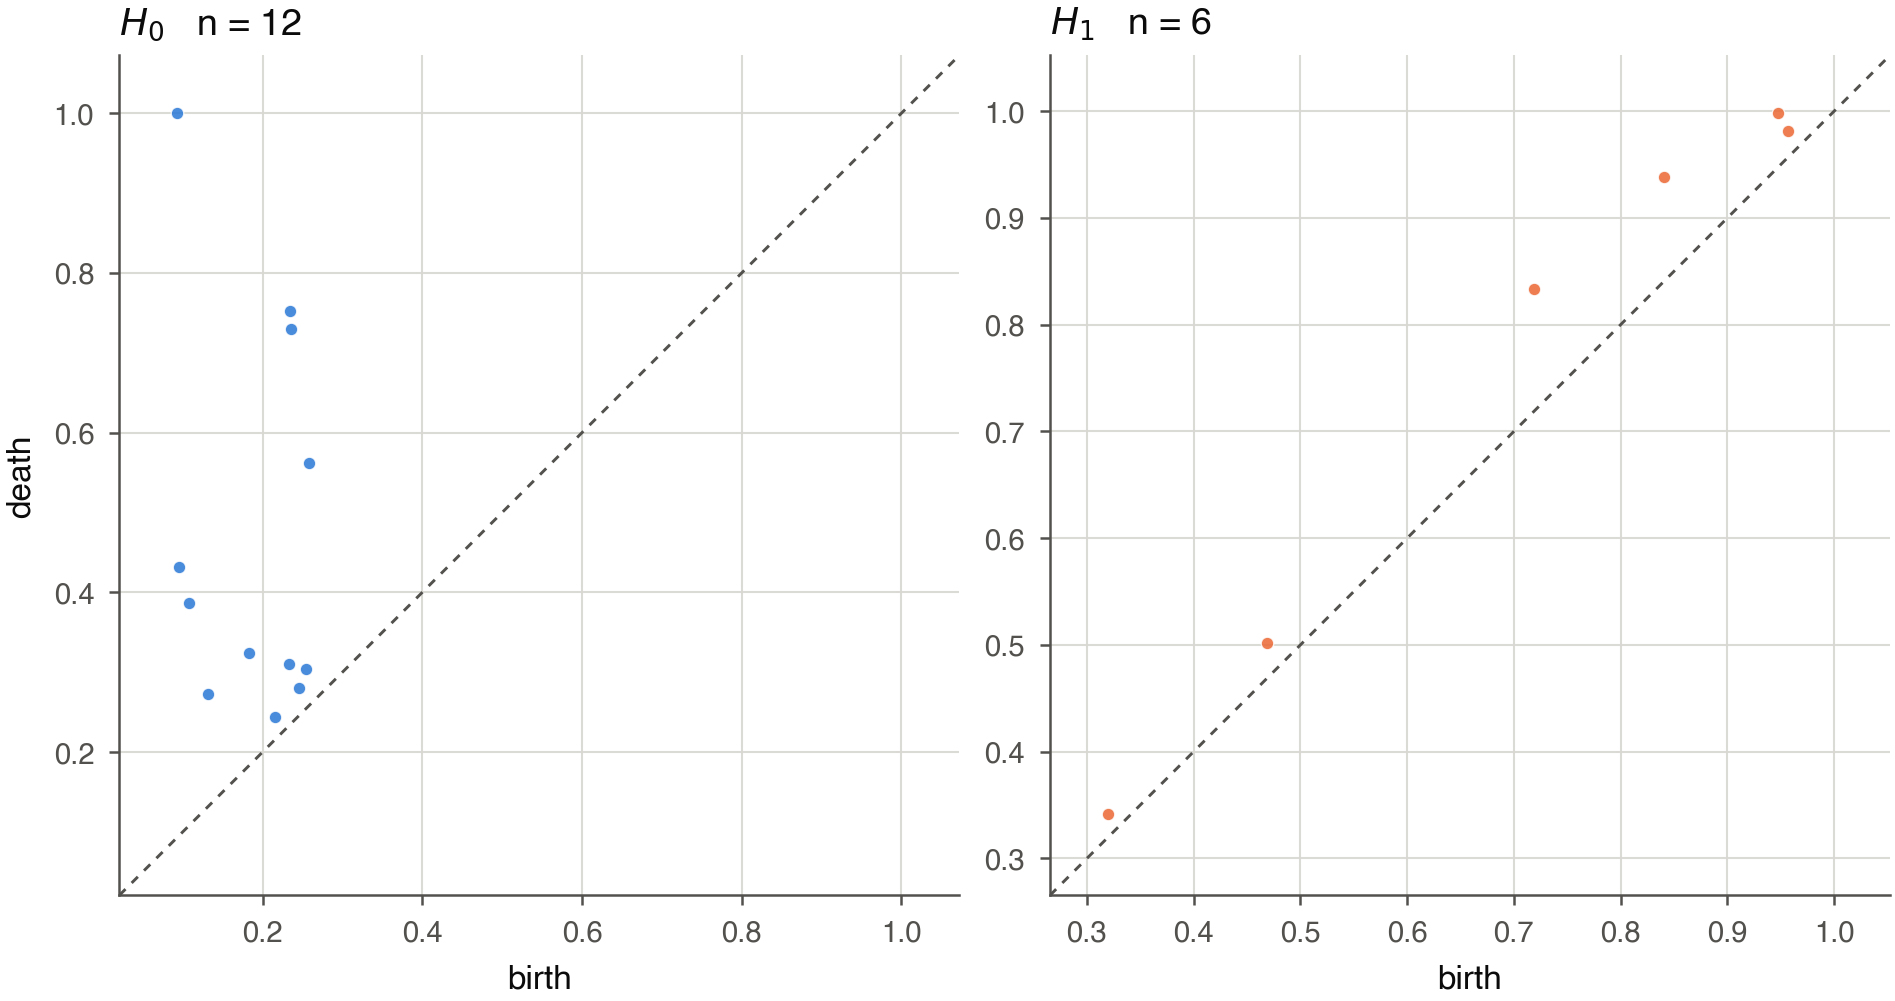

In [5]:
display(Image(filename=str(RESULTS / f'recovery_loss_map_{tag}.png')))
display(Image(filename=str(RESULTS / f'recovery_target_persistence_{tag}.png')))

### Summary

In [6]:
metrics = []
for feature, block in summary['metrics'].items():
    metrics.append({
        'feature_set': feature,
        'n': block['n_single_snapshot_recoveries'],
        'median_R_hat_error_%': 100 * block['median_relative_error']['R_hat'],
        'median_D_hat_error_%': 100 * block['median_relative_error']['D_hat'],
        'median_alpha_error_%': 100 * block['median_relative_error']['alpha'],
        'signed_R_hat_%': 100 * block.get('median_signed_relative_error', {}).get('R_hat', float('nan')),
        'signed_D_hat_%': 100 * block.get('median_signed_relative_error', {}).get('D_hat', float('nan')),
        'D_hat_overestimated_frac': block.get('fraction_overestimated', {}).get('D_hat', float('nan')),
    })
display(pd.DataFrame(metrics).round(3))

,feature_set,n,median_R_hat_error_%,median_D_hat_error_%,median_alpha_error_%,signed_R_hat_%,signed_D_hat_%,D_hat_overestimated_frac
0,h0,64,0.015,0.060,0.050,0.002,0.009,0.531
1,h0h1,64,0.018,0.064,0.075,-0.002,0.009,0.531


## 7. Robustness, and the two observation modes

Each study perturbs one assumption the main sweep holds fixed. The last two figures are the two observation modes, each validated on its own: one field at an unmeasured elapsed time, the mode a biopsy slice supplies, which fixes $\widehat D/\widehat R$ and not a rate; and three fields at known intervals, the mode a movie supplies.

In [7]:
studies = {}
sources = {
    'phase_scramble_control': 'run_phase_control.py',
    'operator_mismatch': 'run_operator_mismatch.py',
    'noise_study': 'run_robustness.py',
    'sigma_sensitivity': 'run_robustness.py',
    'scenarios': 'run_scenarios.py',
}
for name, script in sources.items():
    path = RESULTS / f'{name}_{tag}.json'
    if path.exists():
        studies[name] = json.loads(path.read_text())
    else:
        print(f'missing {path.name} - run scripts/{script} --config configs/{MODEL}.yaml')
print('loaded:', ', '.join(studies))

loaded: phase_scramble_control, operator_mismatch, noise_study, sigma_sensitivity, scenarios


In [8]:
def as_percent(block, key='median_signed'):
    return {p: 100 * block[p][key] for p in ('rhat', 'dhat', 'alpha')}

frames = []
if 'operator_mismatch' in studies:
    for arm, block in studies['operator_mismatch']['by_arm'].items():
        frames.append({'study': 'different operator', 'setting': arm,
                       **as_percent(block)})
if 'noise_study' in studies:
    for eta, block in studies['noise_study']['by_eta'].items():
        frames.append({'study': 'noise', 'setting': f'eta={eta}',
                       **as_percent(block, 'median_absolute')})
if 'sigma_sensitivity' in studies:
    for factor, block in studies['sigma_sensitivity']['by_sigma_factor'].items():
        frames.append({'study': 'sigma misspecified', 'setting': f'sigma x{factor}',
                       **as_percent(block)})

summary_table = pd.DataFrame(frames).rename(columns={
    'rhat': 'R_hat error %', 'dhat': 'D_hat error %', 'alpha': 'alpha error %'})
display(summary_table.round(3))
print('signed medians for the operator and sigma rows; absolute medians for noise')

,study,setting,R_hat error %,D_hat error %,alpha error %
0,different operator,full_mismatch,0.150,2.571,3.107
1,different operator,grid_only,-0.406,2.513,3.157
2,different operator,inverse_crime,-0.002,0.009,0.011
3,different operator,operator_only,-1.164,-2.894,-1.604
4,different operator,substep_only,1.081,1.507,0.148
5,noise,eta=0.0,0.032,0.061,0.093
6,noise,eta=0.02,0.749,2.518,3.233
7,noise,eta=0.05,1.428,5.426,4.939
8,noise,eta=0.1,3.874,9.470,10.929
9,noise,eta=0.15,7.729,18.587,18.260


signed medians for the operator and sigma rows; absolute medians for noise


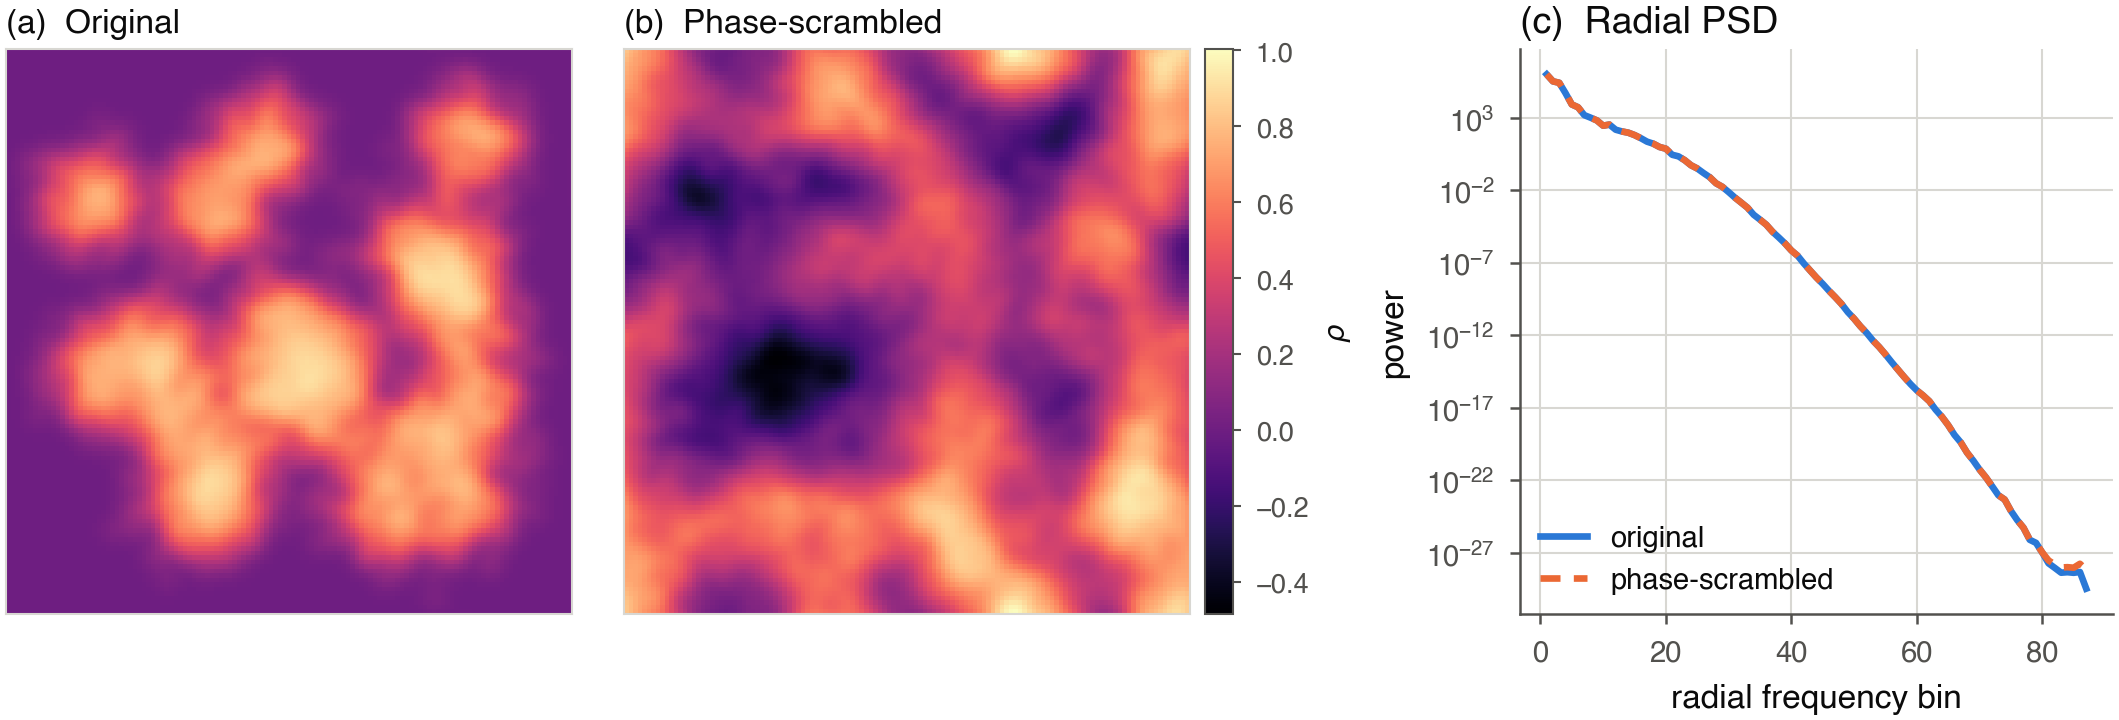

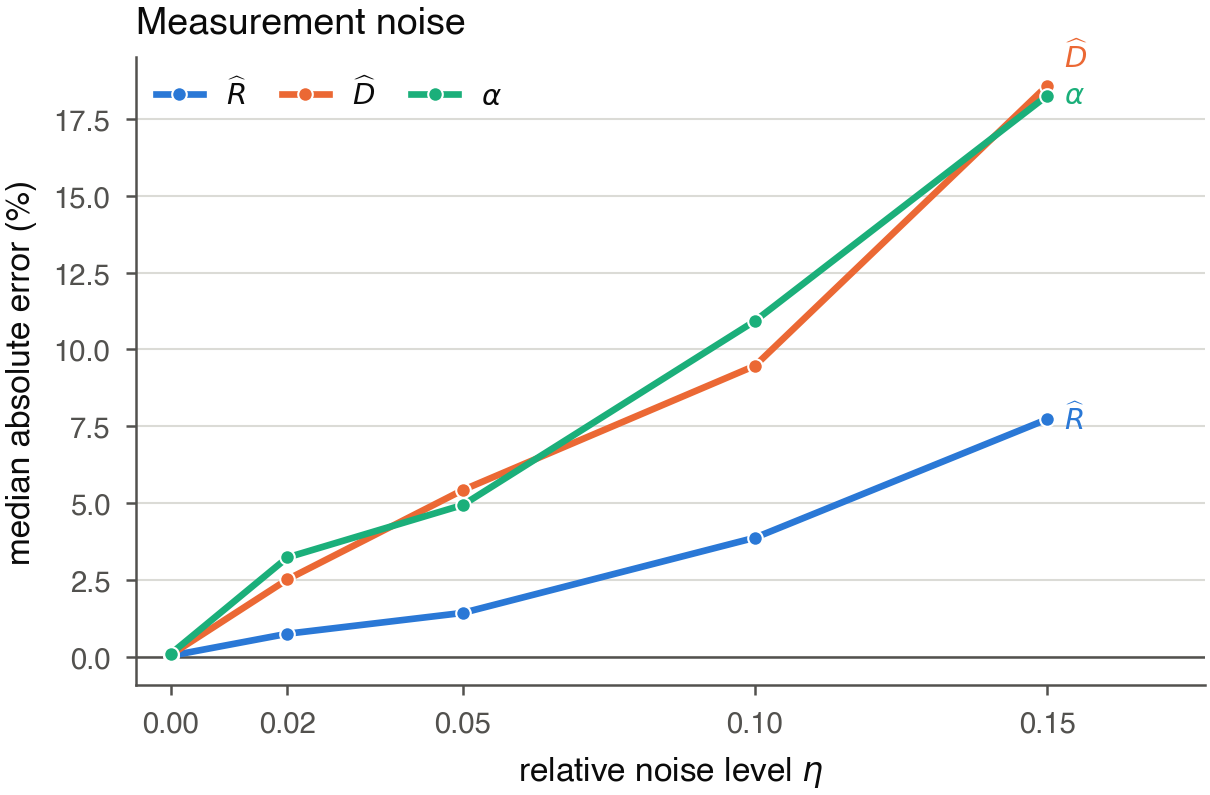

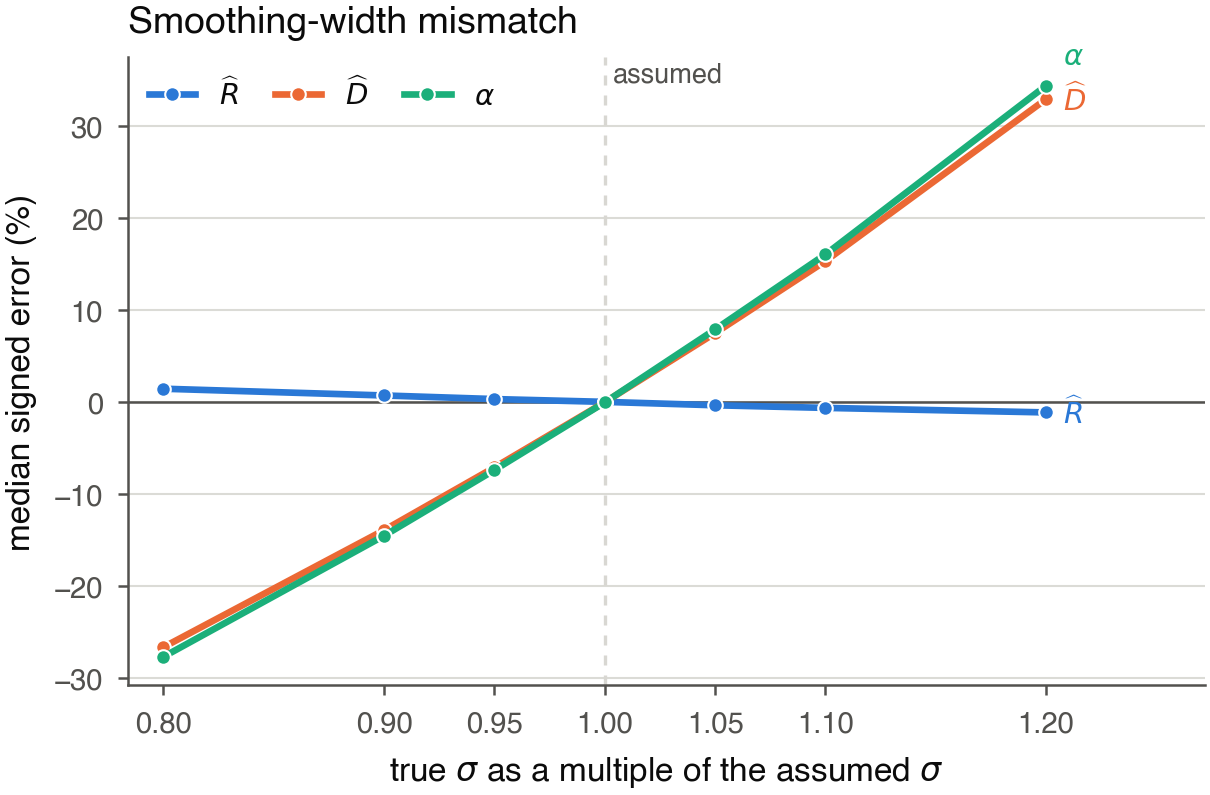

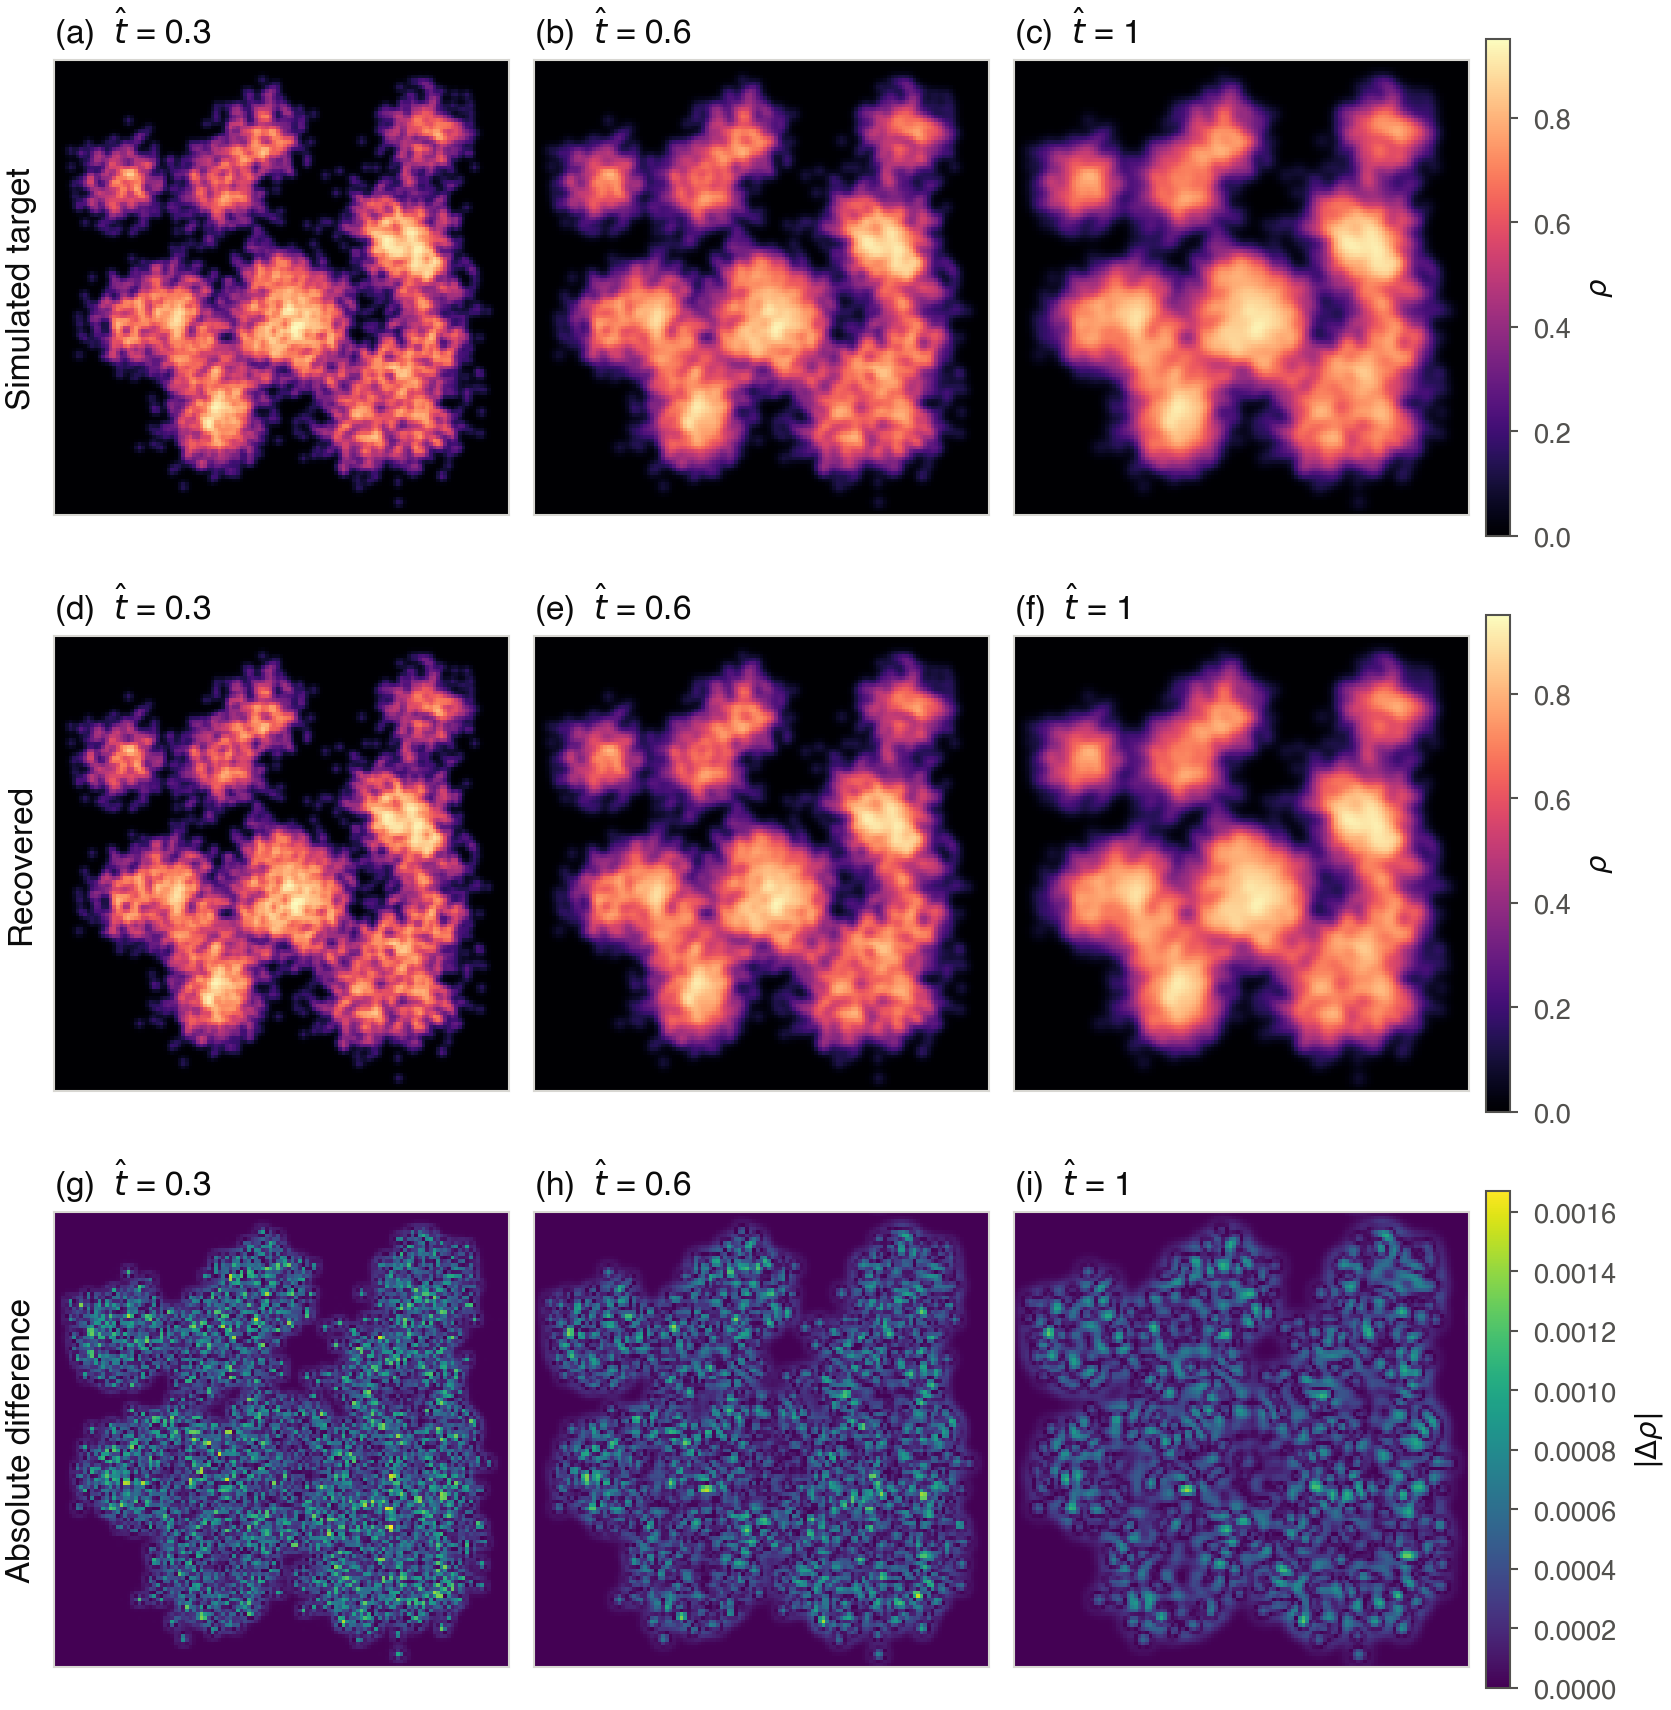

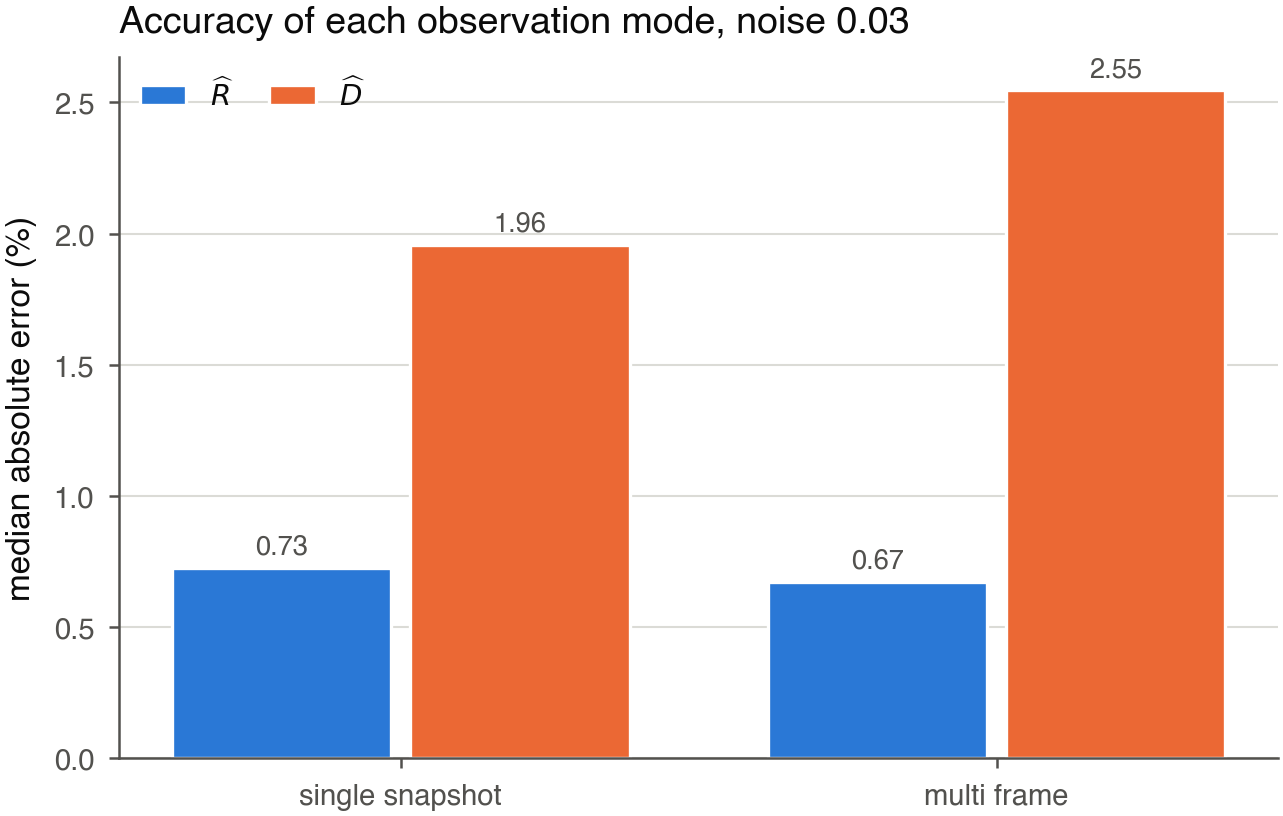

In [9]:
for name in ['phase_scramble_control', 'noise_study',
             'sigma_sensitivity', 'scenario_frames', 'scenarios']:
    path = RESULTS / f'{name}_{tag}.png'
    if path.exists():
        display(Image(filename=str(path)))

In [10]:
if 'sigma_sensitivity' in studies:
    block = studies['sigma_sensitivity']
    print(f"assumed smoothing width (fraction of domain) {block['sigma_hat_assumed']:.4f}")
    print(f"median characteristic length / L0           {block['median_true_length_scale_ratio']:.4f}")
    print(f"length scale / smoothing width              {block['length_scale_to_sigma_ratio']:.2f}")
    print(f"D_hat bias per unit sigma error              {block['dhat_bias_per_unit_sigma_error']:.2f}")

assumed smoothing width (fraction of domain) 0.0120
median characteristic length / L0           0.0120
length scale / smoothing width              1.00
D_hat bias per unit sigma error              1.48


## 8. Run configuration

In [11]:
cfg = summary['config']
print(f"model                     {summary['model']}")
print(f"PDE grid                  {cfg['pde_grid_size']} x {cfg['pde_grid_size']}")
print(f"observation grid          {cfg['observation_grid_size']} x {cfg['observation_grid_size']}")
print(f"smoothing sigma / L0      {cfg['observation_sigma_hat']}")
print(f"bar-length cutoff         {cfg['persistence_cutoff']}")
print(f"homology dimensions       {cfg['homology_dimensions']}")
print(f"candidate library         {len(cfg['rhat_grid'])} x {len(cfg['dhat_grid'])}")
print(f"R_hat bounds              {cfg['rhat_bounds']}")
print(f"D_hat bounds              {cfg['dhat_bounds']}")
print(f"solver substep            target {cfg['target_solver_step']}, candidate {cfg['candidate_solver_step']}")
print(f"refinement                {cfg['refinement_n_starts']} starts, Nelder-Mead "
      f"{cfg['refinement_maxfev_stage1']} + {cfg['refinement_maxfev_stage2']} evaluations")
print(f"holdouts                  {cfg['n_holdouts']}, seed {cfg['holdout_seed']}")
print(f"scale-estimation seed     {cfg['scale_estimation_seed']}")
print()
print(f"config  sha256            {summary['config_sha256'][:16]}")
print(f"method  sha256            {summary['method_sha256'][:16]}")
for name, version in summary['provenance'].items():
    print(f"{name:<26}{version.splitlines()[0]}")

model                     logistic
PDE grid                  125 x 125
observation grid          125 x 125
smoothing sigma / L0      0.012
bar-length cutoff         0.02
homology dimensions       [0, 1]
candidate library         15 x 13
R_hat bounds              [0.28, 1.05]
D_hat bounds              [5.76e-05, 0.000168]
solver substep            target 0.02, candidate 0.02
refinement                2 starts, Nelder-Mead 120 + 80 evaluations
holdouts                  16, seed 20260822
scale-estimation seed     12017

config  sha256            81ebaaea80075706
method  sha256            e6221f2af36f46e5
python                    3.13.9 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 19:11:29) [Clang 20.1.8 ]
platform                  macOS-26.0-arm64-arm-64bit-Mach-O
numpy                     2.3.5
scipy                     1.16.3
gudhi                     3.12.0
matplotlib                3.10.6


## 9. Outputs

$\widehat R$, $\widehat D$, the pair $\tau=\widehat R$, $\alpha=\widehat D/\widehat R$, and $\sqrt{\alpha}$.